<a href="https://colab.research.google.com/github/faith-nyamosi/PNEUMONIA_PROJECT/blob/main/Pneumonia_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing the necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout,Normalization
from  tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2
from sklearn.metrics import classification_report,confusion_matrix
from keras.callbacks import ReduceLROnPlateau
import os

#Pneumonia Dataset

In [ ]:
labels=['PNEUMONIA','NORMAL']
img_resize=150

def get_data(dir):
  data=[]
  for label in labels:
    path=os.path.join(dir,label)
    class_num= labels.index(label)

    for img in os.listdir(path):
      try:
        if img.endswith('.jpeg'):
          img_arr = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
          resized_arr = cv2.resize(img_arr,(img_resize,img_resize))
          data.append((resized_arr,class_num))
      except Exception as e:
          print(e)
  return np.array(data,dtype='object')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train = get_data('/content/drive/MyDrive/Pneumonia_project/chest_xray/train')
val = get_data('/content/drive/MyDrive/Pneumonia_project/chest_xray/val')
test = get_data('/content/drive/MyDrive/Pneumonia_project/chest_xray/test')

#Data Visualization and Preprocessing

<Axes: xlabel='count'>

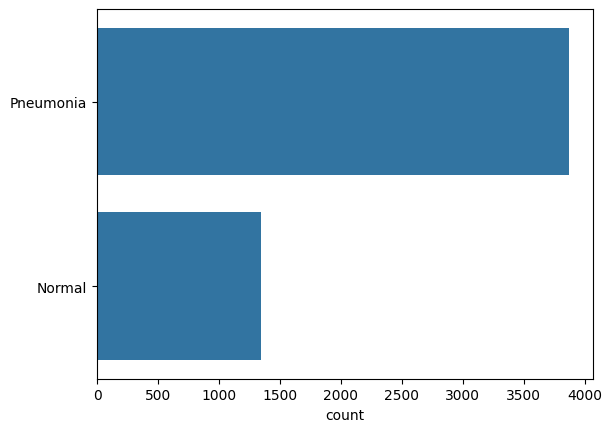

In [ ]:
l = []
for i in train:
  if(i[1]==0):
    l.append('Pneumonia')
  else:
    l.append('Normal')

sns.countplot(l)

Text(0.5, 1.0, 'NORMAL')

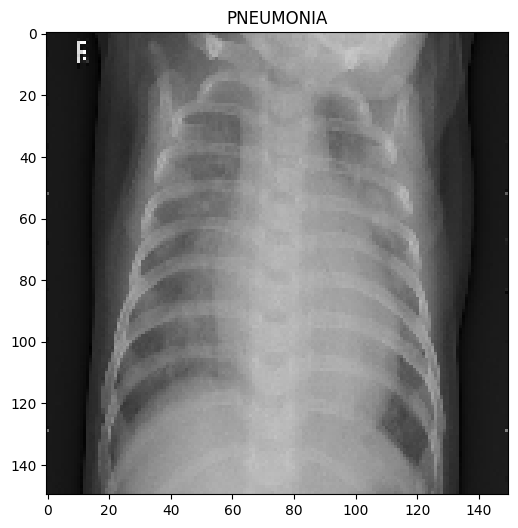

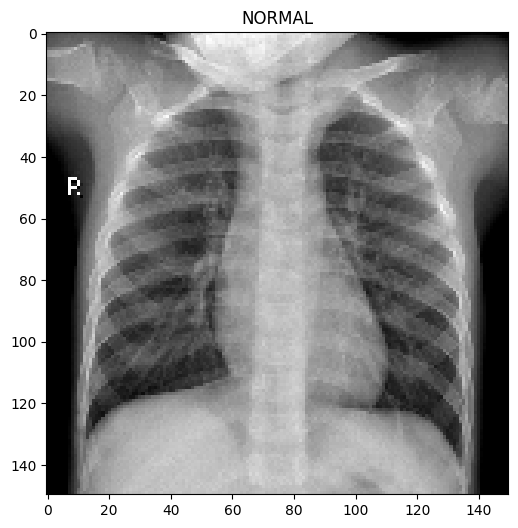

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))

plt.imshow(train[-1][0], cmap='gray')
plt.title(labels[train[-1][1]])

In [ ]:
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

for feat, label in train:
  x_train.append(feat)
  y_train.append(label)

for feat, label in val:
  x_val.append(feat)
  y_val.append(label)

for feat, label in test:
  x_test.append(feat)
  y_test.append(label)


In [ ]:
#Normalize the data
x_train = np.array(x_train)/255
x_val = np.array(x_val)/255
x_test = np.array(x_test)/255

In [ ]:
x_train = x_train.reshape(-1, img_resize, img_resize, 1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1, img_resize, img_resize, 1)
y_val = np.array(y_val)

x_test = x_test.reshape(-1, img_resize, img_resize, 1)
y_test = np.array(y_test)




In [ ]:
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,

)

datagen.fit(x_train)

##Training the Model

In [ ]:

model = Sequential()
model.add(Conv2D(32,(3,3),strides =1,padding='same',activation='relu',input_shape=(150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(64,(3,3),strides =1,padding='same',activation='relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(64,(3,3),strides =1,padding='same',activation='relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(128,(3,3),strides =1,padding='same',activation='relu')) # Corrected model.() to model.add()
model.add(Dropout(0.2)) # Corrected parentheses
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(256,(3,3),strides =1,padding='same',activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Flatten()) # Corrected missing parenthesis
model.add(Dense(units=128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [ ]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',patience=2,verbose=1,factor=0.3,min_lr=0.000001)

In [ ]:
history = model.fit(x_train,y_train,batch_size=32,epochs=18,
                    validation_data=datagen.flow(x_val,y_val),
                    callbacks=[learning_rate_reduction])

Epoch 1/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8604 - loss: 1.1740

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


163/163 ━━━━━━━━━━━━━━━━━━━━ 465s 3s/step - accuracy: 0.8606 - loss: 1.1696 - val_accuracy: 0.5000 - val_loss: 34.4565 - learning_rate: 0.0010
Epoch 2/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 511s 3s/step - accuracy: 0.9453 - loss: 0.1365 - val_accuracy: 0.5000 - val_loss: 32.5633 - learning_rate: 0.0010
Epoch 3/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9667 - loss: 0.1018
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
163/163 ━━━━━━━━━━━━━━━━━━━━ 493s 3s/step - accuracy: 0.9667 - loss: 0.1017 - val_accuracy: 0.5000 - val_loss: 33.7958 - learning_rate: 0.0010
Epoch 4/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 513s 3s/step - accuracy: 0.9865 - loss: 0.0414 - val_accuracy: 0.5000 - val_loss: 38.5947 - learning_rate: 3.0000e-04
Epoch 5/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9898 - loss: 0.0273
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 463s 3s/step - accuracy: 0.9898 - loss: 0.0273 - va

In [ ]:
model.evaluate(x_test,y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 637ms/step - accuracy: 0.9210 - loss: 1.1668


[4.255391597747803, 0.7243589758872986]

In [ ]:
print(f"Loss of the model is {model.evaluate(x_test,y_test)[0]}")
print(f"Accuracy of the model is {model.evaluate(x_test,y_test)[1]*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 562ms/step - accuracy: 0.9210 - loss: 1.1668
Loss of the model is 4.255391597747803
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 537ms/step - accuracy: 0.9210 - loss: 1.1668
Accuracy of the model is 72.44%


##Analyse Model Performance

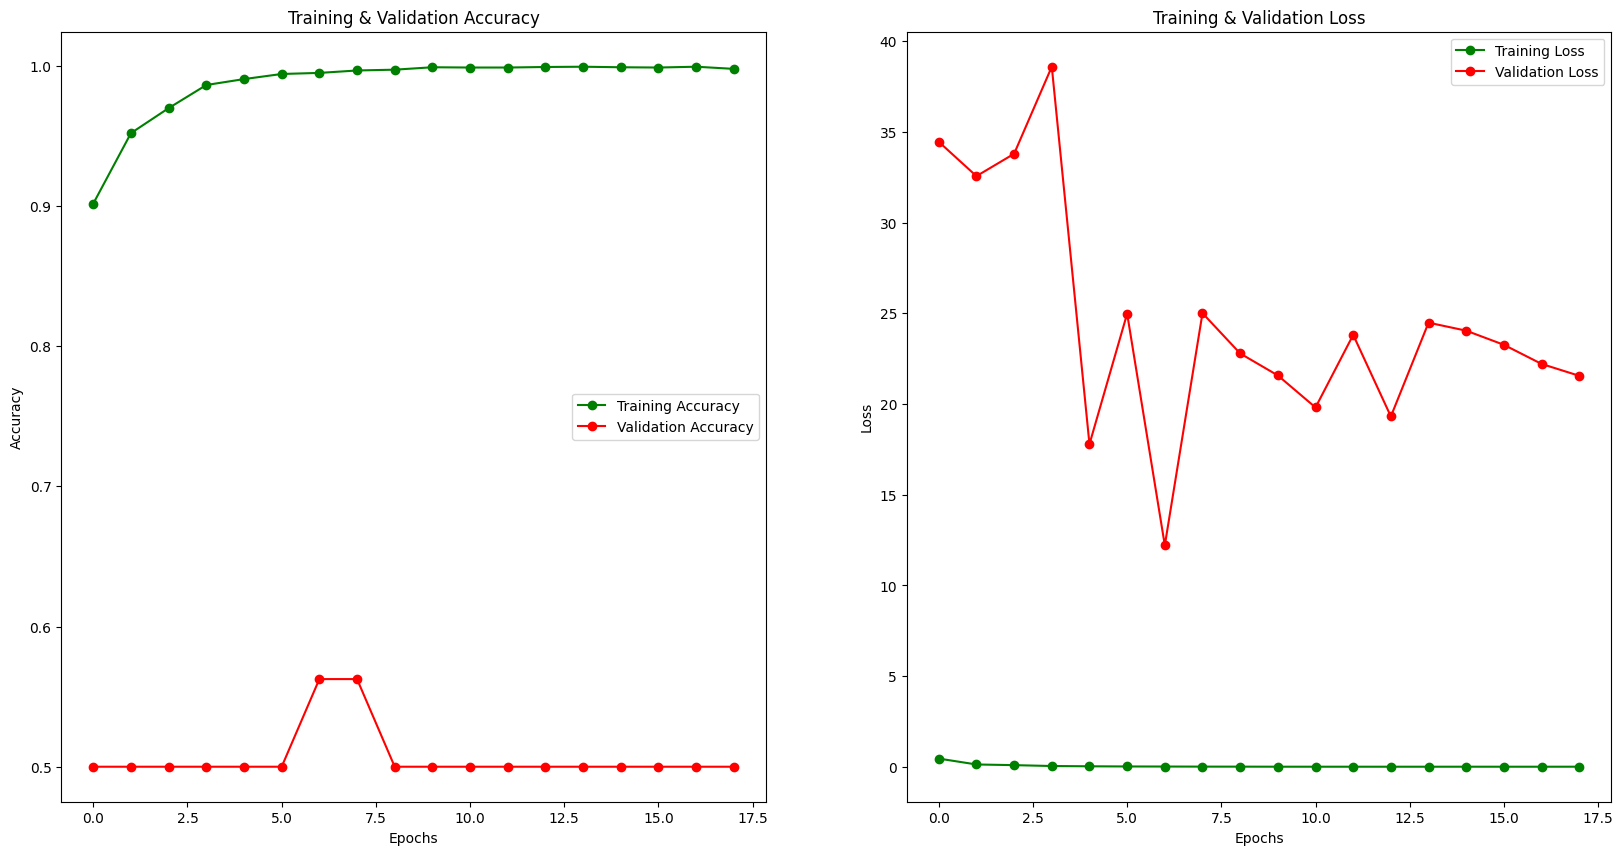

In [ ]:
epochs = [i for i in range(18)]
fig, ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.set_size_inches(20,10)

ax[0].plot(epochs,train_acc,'go-',label='Training Accuracy')
ax[0].plot(epochs,val_acc,'ro-',label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs,train_loss,'go-',label='Training Loss')
ax[1].plot(epochs,val_loss,'ro-',label='Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
plt.show()

In [ ]:
predictions = (model.predict(x_test)>0.5).astype('int32')
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 571ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [ ]:
print(classification_report(y_test,predictions,target_names=('Pneumonia (class 0)','Normal (class 1)')))

                     precision    recall  f1-score   support

Pneumonia (class 0)       0.69      1.00      0.82       390
   Normal (class 1)       1.00      0.26      0.42       234

           accuracy                           0.72       624
          macro avg       0.85      0.63      0.62       624
       weighted avg       0.81      0.72      0.67       624



In [ ]:
cm = confusion_matrix(y_test,predictions)


In [ ]:
cm

array([[390,   0],
       [172,  62]])

In [ ]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions == y_test)[0]

#Some Correctly Predicted Classes

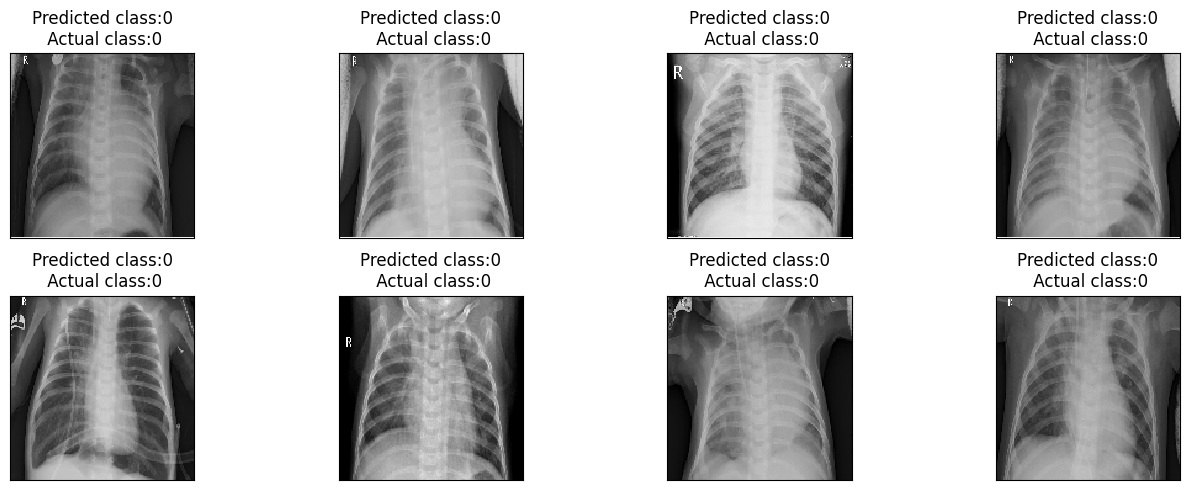

In [ ]:
i = 0
plt.figure(figsize=(16,5))

for c in correct[10:18]:
  plt.subplot(2,4,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150),cmap='gray',interpolation='none')
  plt.title(f"Predicted class:{predictions[c]}\n Actual class:{y_test[c]}")
  plt.tight_layout()
  i += 1

#Some Incorrectly Predicted Classes

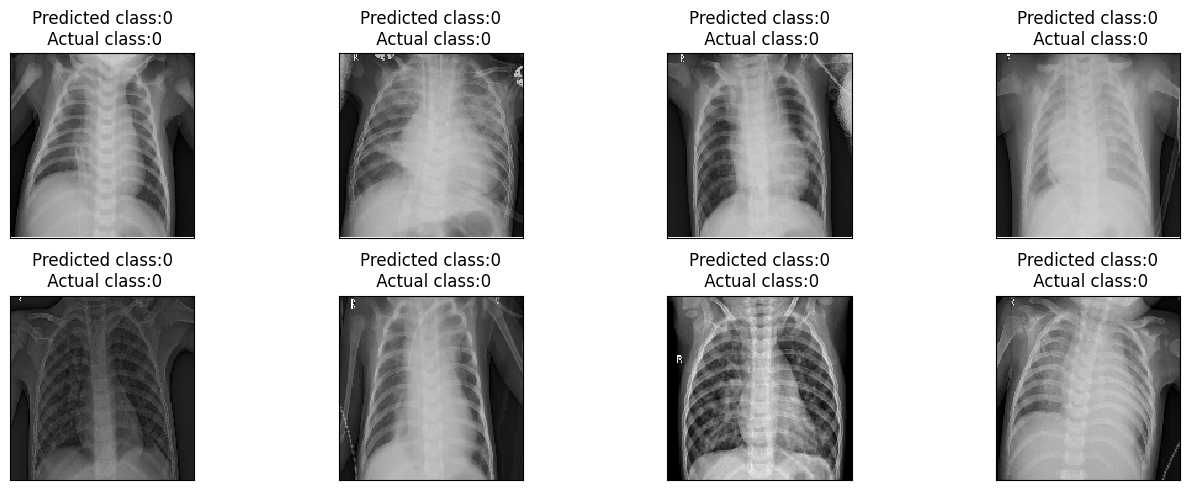

In [ ]:
i = 0
plt.figure(figsize=(16,5))

for c in incorrect[40:48]:
  plt.subplot(2,4,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150),cmap='gray',interpolation='none')
  plt.title(f"Predicted class:{predictions[c]}\n Actual class:{y_test[c]}")
  plt.tight_layout()
  i += 1